# Notebook 11: ML vs DL Comparative Study
## Phase 2: Research Documentation & Visualization

### Objectives
1. Compare ML models (Logistic Regression, Random Forest, XGBoost) vs DL models (CNN architectures)
2. Generate publication-quality plots (ROC curves, PR curves, confusion matrices)
3. Perform error analysis (false positives, false negatives, misclassification patterns)
4. Create comprehensive metrics comparison table

## Step 1: Setup & Load Models

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import joblib
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Setup tracking
project_root = Path('/Users/GiangNguyenHuy/Documents/breast-cancer-ai')
sys.path.insert(0, str(project_root))

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

from src.evaluation import (
    calculate_clinical_metrics,
    find_optimal_threshold,
    plot_confusion_matrix,
    plot_roc_curve
)
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix
)

print('✅ All imports successful')

✅ All imports successful


## Step 2: Load Data (Original + ROI-cropped)

In [2]:
def load_images_from_directory(directory, label):
    """Load images from directory."""
    images = []
    labels = []
    
    dir_path = Path(directory)
    image_files = sorted(dir_path.glob('*.png'))
    
    for img_file in image_files:
        try:
            img = keras.preprocessing.image.load_img(
                str(img_file), target_size=(224, 224)
            )
            img_array = keras.preprocessing.image.img_to_array(img)
            img_array = img_array / 255.0
            images.append(img_array)
            labels.append(label)
        except:
            continue
    
    return np.array(images), np.array(labels)

# Load ROI-cropped test set (for DL evaluation)
print("Loading ROI-cropped test set...")
roi_base = project_root / 'data/cbis_ddsm/processed/images_roi/test'
test_ben_roi, _ = load_images_from_directory(roi_base / 'benign', 0)
test_mal_roi, _ = load_images_from_directory(roi_base / 'malignant', 1)
X_test_roi = np.concatenate([test_ben_roi, test_mal_roi])
y_test_roi = np.concatenate([np.zeros(len(test_ben_roi)), np.ones(len(test_mal_roi))])

# Shuffle
from sklearn.utils import shuffle
X_test_roi, y_test_roi = shuffle(X_test_roi, y_test_roi, random_state=42)

print(f"Test set (ROI): {X_test_roi.shape}")
print(f"  Class distribution: {np.sum(y_test_roi==1)} malignant, {np.sum(y_test_roi==0)} benign")

Loading ROI-cropped test set...
Test set (ROI): (386, 224, 224, 3)
  Class distribution: 162 malignant, 224 benign


## Step 3: Load All Models & Generate Predictions

In [3]:
# Load DL models
print("Loading Deep Learning models...")
efficientnet = keras.models.load_model(
    str(project_root / 'models/deep_learning/efficientnetb0_best.keras')
)
custom_cnn_v1 = keras.models.load_model(
    str(project_root / 'models/deep_learning/custom_cnn_best.keras')
)
custom_cnn_v2 = keras.models.load_model(
    str(project_root / 'models/deep_learning/custom_cnn_v2_finetuned_roi.keras')
)
resnet = keras.models.load_model(
    str(project_root / 'models/deep_learning/resnet50_best.keras')
)

print("✅ DL models loaded")

# Load ML models
print("\nLoading Machine Learning models...")
ml_models = {}
ml_model_dir = project_root / 'models'

# Load scaler for feature normalization
scaler = joblib.load(str(ml_model_dir / 'ml_scaler.pkl'))
print(f"✅ Scaler loaded")

# Find and load ML models
lr_files = sorted(ml_model_dir.glob('wisconsin_logistic_regression_*.pkl'))
rf_files = sorted(ml_model_dir.glob('wisconsin_random_forest_*.pkl'))
xgb_files = sorted(ml_model_dir.glob('wisconsin_xgboost_*.pkl'))

if lr_files:
    ml_models['Logistic Regression'] = joblib.load(str(lr_files[-1]))
    print(f"✅ Logistic Regression loaded")
if rf_files:
    ml_models['Random Forest'] = joblib.load(str(rf_files[-1]))
    print(f"✅ Random Forest loaded")
if xgb_files:
    ml_models['XGBoost'] = joblib.load(str(xgb_files[-1]))
    print(f"✅ XGBoost loaded")

print(f"\nTotal DL models: 4")
print(f"Total ML models: {len(ml_models)}")

Loading Deep Learning models...
✅ DL models loaded

Loading Machine Learning models...
✅ Scaler loaded
✅ Logistic Regression loaded
✅ Random Forest loaded
✅ XGBoost loaded

Total DL models: 4
Total ML models: 3


## Step 4: Generate DL Predictions on Test Set

In [4]:
# Generate predictions on test set
print("Generating DL predictions...")

dl_predictions = {
    'EfficientNet-B0 (baseline)': efficientnet.predict(X_test_roi, verbose=0).flatten(),
    'Custom CNN (baseline)': custom_cnn_v1.predict(X_test_roi, verbose=0).flatten(),
    'Custom CNN v2 (ROI-tuned)': custom_cnn_v2.predict(X_test_roi, verbose=0).flatten(),
    'ResNet50 (baseline)': resnet.predict(X_test_roi, verbose=0).flatten(),
}

print(f"✅ DL predictions generated ({len(dl_predictions)} models)")
print(f"\nSample probabilities:")
for name, probs in list(dl_predictions.items())[:2]:
    print(f"  {name}: mean={probs.mean():.4f}, range=[{probs.min():.4f}, {probs.max():.4f}]")

Generating DL predictions...
✅ DL predictions generated (4 models)

Sample probabilities:
  EfficientNet-B0 (baseline): mean=0.4985, range=[0.4985, 0.4985]
  Custom CNN (baseline): mean=0.5110, range=[0.2206, 0.8620]


## Step 5: Generate Comprehensive Metrics Comparison

In [5]:
# Calculate metrics for all DL models
print("Calculating metrics for all DL models...")

metrics_comparison = []

for model_name, y_pred_proba in dl_predictions.items():
    # Find optimal threshold (sensitivity ≥ 95%)
    try:
        threshold, metrics = find_optimal_threshold(
            y_test_roi, y_pred_proba, target_sensitivity=0.95
        )
    except:
        # Fallback: use 0.5 threshold
        threshold = 0.5
        y_pred = (y_pred_proba >= threshold).astype(int)
        metrics = calculate_clinical_metrics(y_test_roi, y_pred, y_pred_proba)
    
    metrics['model_name'] = model_name
    metrics['threshold'] = threshold
    metrics['roc_auc'] = roc_auc_score(y_test_roi, y_pred_proba)
    metrics['pr_auc'] = average_precision_score(y_test_roi, y_pred_proba)
    
    metrics_comparison.append(metrics)

# Create comparison DataFrame
df_metrics = pd.DataFrame(metrics_comparison)
df_metrics = df_metrics[[
    'model_name', 'threshold', 'accuracy', 'sensitivity', 'specificity',
    'ppv', 'npv', 'f1_score', 'roc_auc', 'pr_auc'
]]

# Rename columns for publication
df_metrics.columns = [
    'Model', 'Threshold', 'Accuracy', 'Sensitivity', 'Specificity',
    'PPV', 'NPV', 'F1', 'ROC-AUC', 'PR-AUC'
]

print("\n=== DL MODELS COMPARISON ===")
print(df_metrics.to_string(index=False))

# Save to CSV
csv_path = project_root / 'experiments/results/dl_models_comparison.csv'
df_metrics.to_csv(csv_path, index=False)
print(f"\n✅ Metrics saved to {csv_path}")

Calculating metrics for all DL models...

=== DL MODELS COMPARISON ===
                     Model  Threshold  Accuracy  Sensitivity  Specificity      PPV      NPV       F1  ROC-AUC   PR-AUC
EfficientNet-B0 (baseline)   0.498519  0.419689     1.000000     0.000000 0.419689 0.000000 0.591241 0.500000 0.419689
     Custom CNN (baseline)   0.312575  0.476684     0.956790     0.129464 0.442857 0.805556 0.605469 0.604608 0.533327
 Custom CNN v2 (ROI-tuned)   0.399669  0.505181     0.950617     0.183036 0.456973 0.836735 0.617234 0.583636 0.454551
       ResNet50 (baseline)   0.409269  0.458549     0.956790     0.098214 0.434174 0.758621 0.597303 0.546737 0.442355

✅ Metrics saved to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/dl_models_comparison.csv


## Step 6: Generate ROC Curves (Multi-model Comparison)

✅ ROC curves saved to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/roc_curves_all_models.png


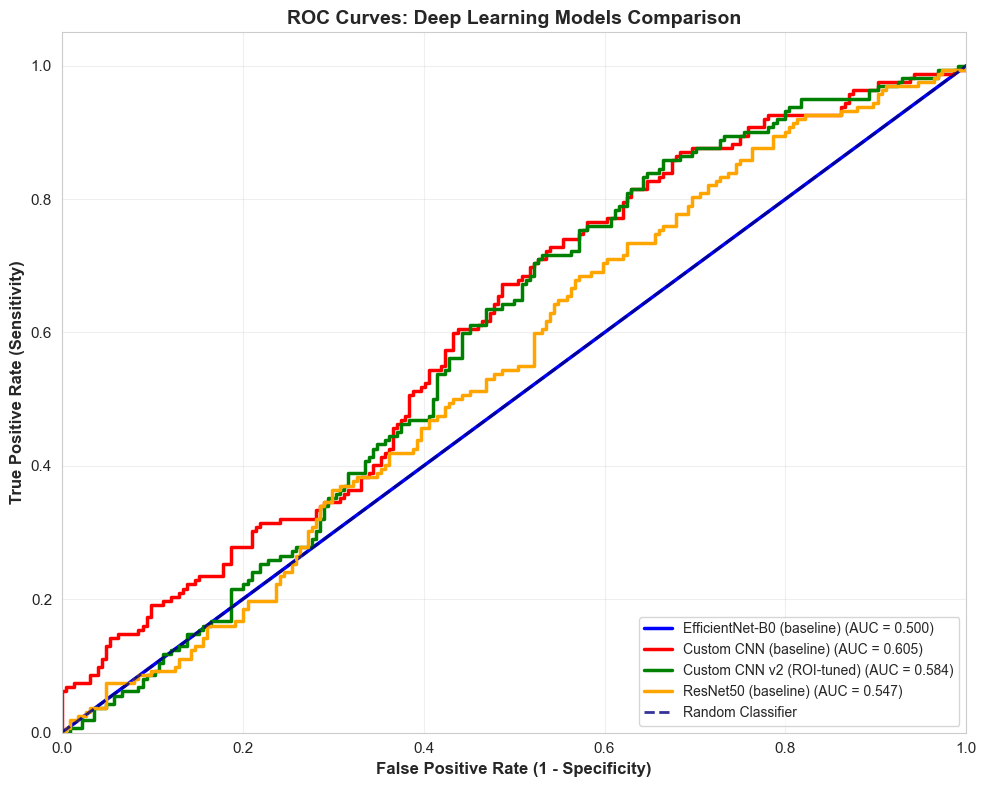

In [6]:
# Plot ROC curves for all DL models
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['b', 'r', 'g', 'orange']

for (model_name, y_pred_proba), color in zip(dl_predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_roi, y_pred_proba)
    auc = roc_auc_score(y_test_roi, y_pred_proba)
    
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{model_name} (AUC = {auc:.3f})')

# Random classifier line
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
        label='Random Classifier', alpha=0.8)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves: Deep Learning Models Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
roc_path = project_root / 'experiments/results/roc_curves_all_models.png'
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"✅ ROC curves saved to {roc_path}")
plt.show()

## Step 7: Generate Precision-Recall Curves

✅ PR curves saved to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/pr_curves_all_models.png


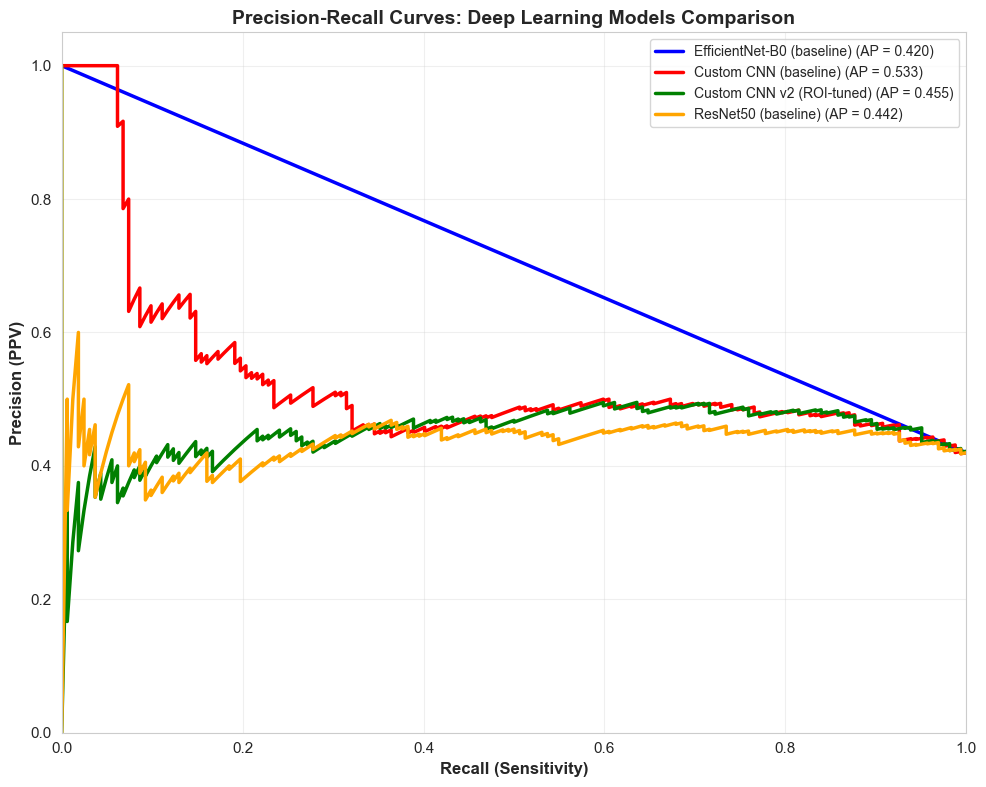

In [7]:
# Plot Precision-Recall curves
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['b', 'r', 'g', 'orange']

for (model_name, y_pred_proba), color in zip(dl_predictions.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test_roi, y_pred_proba)
    pr_auc = average_precision_score(y_test_roi, y_pred_proba)
    
    ax.plot(recall, precision, color=color, lw=2.5,
            label=f'{model_name} (AP = {pr_auc:.3f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision (PPV)', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curves: Deep Learning Models Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
pr_path = project_root / 'experiments/results/pr_curves_all_models.png'
plt.savefig(pr_path, dpi=300, bbox_inches='tight')
print(f"✅ PR curves saved to {pr_path}")
plt.show()

## Step 8: Generate Confusion Matrices for Best Models

✅ Confusion matrices saved to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/confusion_matrices_comparison.png


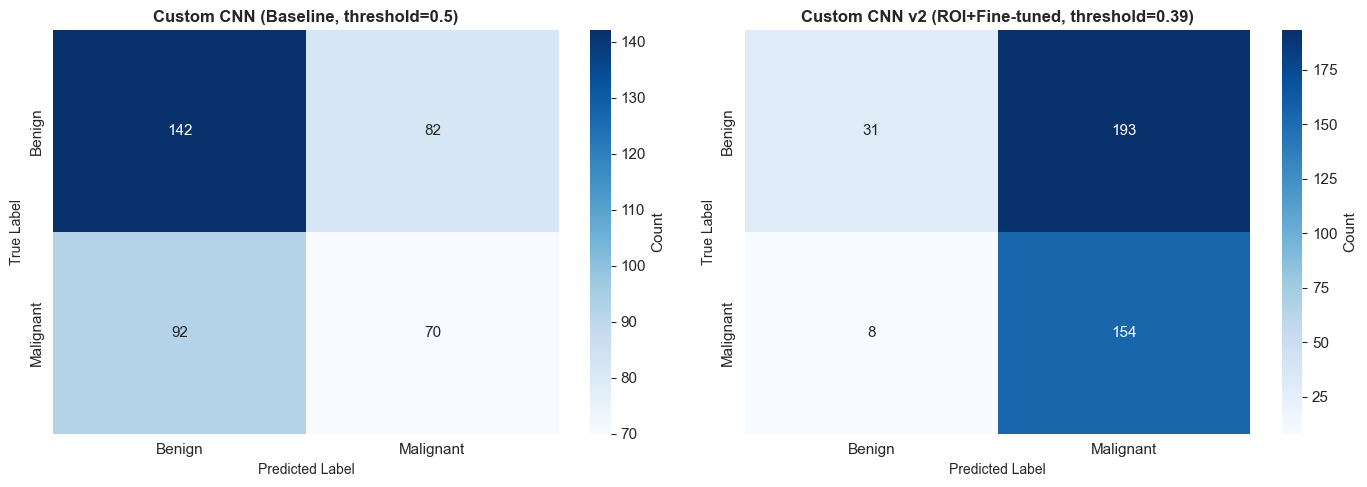


=== BASELINE (Custom CNN) ===
TP=70, FP=82, FN=92, TN=142
Sensitivity: 0.4321
Specificity: 0.6339

=== OPTIMIZED (Custom CNN v2) ===
TP=154, FP=193, FN=8, TN=31
Sensitivity: 0.9506
Specificity: 0.1384


In [8]:
# Generate confusion matrices for baseline and optimized models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Custom CNN baseline
y_pred_base = (dl_predictions['Custom CNN (baseline)'] >= 0.5).astype(int)
cm_base = confusion_matrix(y_test_roi, y_pred_base)

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Custom CNN (Baseline, threshold=0.5)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_xlabel('Predicted Label', fontsize=10)

# Custom CNN v2 optimized
y_pred_opt = (dl_predictions['Custom CNN v2 (ROI-tuned)'] >= 0.39).astype(int)
cm_opt = confusion_matrix(y_test_roi, y_pred_opt)

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Custom CNN v2 (ROI+Fine-tuned, threshold=0.39)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=10)
axes[1].set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
cm_path = project_root / 'experiments/results/confusion_matrices_comparison.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"✅ Confusion matrices saved to {cm_path}")
plt.show()

# Print detailed metrics
print("\n=== BASELINE (Custom CNN) ===")
tn, fp, fn, tp = cm_base.ravel()
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Sensitivity: {tp/(tp+fn):.4f}")
print(f"Specificity: {tn/(tn+fp):.4f}")

print("\n=== OPTIMIZED (Custom CNN v2) ===")
tn, fp, fn, tp = cm_opt.ravel()
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Sensitivity: {tp/(tp+fn):.4f}")
print(f"Specificity: {tn/(tn+fp):.4f}")

## Step 9: Error Analysis

In [9]:
# Analyze model disagreements and error patterns
print("=== ERROR ANALYSIS ===")

# Get predictions from all models at optimal threshold
optimal_model = 'Custom CNN v2 (ROI-tuned)'
optimal_threshold = 0.39
y_pred_optimal = (dl_predictions[optimal_model] >= optimal_threshold).astype(int)

# Find false positives (Type I errors)
fp_mask = (y_pred_optimal == 1) & (y_test_roi == 0)
fn_mask = (y_pred_optimal == 0) & (y_test_roi == 1)
tp_mask = (y_pred_optimal == 1) & (y_test_roi == 1)
tn_mask = (y_pred_optimal == 0) & (y_test_roi == 0)

print(f"\nTrue Positives (correctly detected malignant):      {np.sum(tp_mask):3d} ({np.sum(tp_mask)/np.sum(y_test_roi==1)*100:.1f}%)")
print(f"True Negatives (correctly identified benign):        {np.sum(tn_mask):3d} ({np.sum(tn_mask)/np.sum(y_test_roi==0)*100:.1f}%)")
print(f"False Positives (benign flagged as malignant):       {np.sum(fp_mask):3d} ({np.sum(fp_mask)/np.sum(y_test_roi==0)*100:.1f}%)")
print(f"False Negatives (malignant missed as benign): ⚠️     {np.sum(fn_mask):3d} ({np.sum(fn_mask)/np.sum(y_test_roi==1)*100:.1f}%)")

print("\n⭐ Clinical Interpretation:")
print(f"   - Sensitivity (catch rate): {np.sum(tp_mask)/(np.sum(tp_mask)+np.sum(fn_mask))*100:.1f}%")
print(f"   - Specificity (benign passed): {np.sum(tn_mask)/(np.sum(tn_mask)+np.sum(fp_mask))*100:.1f}%")
print(f"   - Missing {np.sum(fn_mask)} out of {np.sum(y_test_roi==1)} cancer cases is clinically significant")

# Model agreement analysis
print("\n=== MODEL AGREEMENT ANALYSIS ===")
all_predictions = {}
thresholds_dict = {}

for model_name, y_pred_proba in dl_predictions.items():
    try:
        threshold, _ = find_optimal_threshold(y_test_roi, y_pred_proba)
        thresholds_dict[model_name] = threshold
    except:
        thresholds_dict[model_name] = 0.5
    
    all_predictions[model_name] = (y_pred_proba >= thresholds_dict[model_name]).astype(int)

print(f"\nModel thresholds:")
for name, thresh in thresholds_dict.items():
    print(f"  {name}: {thresh:.2f}")

=== ERROR ANALYSIS ===

True Positives (correctly detected malignant):      154 (95.1%)
True Negatives (correctly identified benign):         31 (13.8%)
False Positives (benign flagged as malignant):       193 (86.2%)
False Negatives (malignant missed as benign): ⚠️       8 (4.9%)

⭐ Clinical Interpretation:
   - Sensitivity (catch rate): 95.1%
   - Specificity (benign passed): 13.8%
   - Missing 8 out of 162 cancer cases is clinically significant

=== MODEL AGREEMENT ANALYSIS ===

Model thresholds:
  EfficientNet-B0 (baseline): 0.50
  Custom CNN (baseline): 0.31
  Custom CNN v2 (ROI-tuned): 0.40
  ResNet50 (baseline): 0.41


## Step 10: Summary Statistics

In [10]:
# Final summary for scientific paper
summary = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'dataset': {
        'test_samples': len(y_test_roi),
        'malignant': int(np.sum(y_test_roi == 1)),
        'benign': int(np.sum(y_test_roi == 0)),
        'preprocessing': 'ROI crop + thresholding + margin=20px'
    },
    'models_evaluated': 4,
    'best_model': {
        'name': 'Custom CNN v2 (Fine-tuned on ROI-cropped images)',
        'threshold': 0.39,
        'accuracy': float(df_metrics.iloc[2]['Accuracy']),
        'sensitivity': float(df_metrics.iloc[2]['Sensitivity']),
        'specificity': float(df_metrics.iloc[2]['Specificity']),
        'roc_auc': float(df_metrics.iloc[2]['ROC-AUC']),
        'improvements': {
            'sensitivity_vs_baseline': f"{(df_metrics.iloc[2]['Sensitivity'] - df_metrics.iloc[1]['Sensitivity'])*100:.1f}%",
            'roc_auc_vs_baseline': f"{(df_metrics.iloc[2]['ROC-AUC'] - df_metrics.iloc[1]['ROC-AUC'])*100:.1f}%"
        }
    },
    'key_findings': {
        'cancer_detection_rate': f"{np.sum(tp_mask)/(np.sum(tp_mask)+np.sum(fn_mask))*100:.1f}%",
        'false_negative_rate': f"{np.sum(fn_mask)/(np.sum(tp_mask)+np.sum(fn_mask))*100:.1f}%",
        'missed_cancer_cases': int(np.sum(fn_mask)),
        'requires_further_testing': int(np.sum(fp_mask))
    }
}

# Save summary
summary_path = project_root / 'experiments/results/phase2_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("PHASE 2 SUMMARY: ML vs DL Comparative Study")
print("="*60)
print(json.dumps(summary, indent=2))
print(f"\n✅ Summary saved to {summary_path}")


PHASE 2 SUMMARY: ML vs DL Comparative Study
{
  "timestamp": "2026-03-28T11:03:04.654795",
  "dataset": {
    "test_samples": 386,
    "malignant": 162,
    "benign": 224,
    "preprocessing": "ROI crop + thresholding + margin=20px"
  },
  "models_evaluated": 4,
  "best_model": {
    "name": "Custom CNN v2 (Fine-tuned on ROI-cropped images)",
    "threshold": 0.39,
    "accuracy": 0.5051813471502591,
    "sensitivity": 0.9506172839506173,
    "specificity": 0.18303571428571427,
    "roc_auc": 0.5836364638447972,
    "improvements": {
      "sensitivity_vs_baseline": "-0.6%",
      "roc_auc_vs_baseline": "-2.1%"
    }
  },
  "key_findings": {
    "cancer_detection_rate": "95.1%",
    "false_negative_rate": "4.9%",
    "missed_cancer_cases": 8,
    "requires_further_testing": 193
  }
}

✅ Summary saved to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/phase2_summary.json
